# Detecção de fraude em cartão de crédito

Transações reais de cartões europeus, em dois dias de setembro de 2013, publicadas pelo Machine Learning Group da Université Libre de Bruxelles. A base tem as colunas `Time`, `Amount` e `Class`, além de `V1` a `V28`, que já passaram por PCA para não expor o dado original do cliente.

O alvo é `Class`: **1 = fraude** e **0 = transação legítima**. Fraude é rara (cerca de 0,17% das linhas). Um modelo que responde "não é fraude" para tudo acerta quase sempre e não pega nenhum caso. Por isso a leitura aqui sai da acurácia e vai para **recall, precisão e F1 da classe fraude**.

O arquivo CSV **não fica neste repositório**. O notebook baixa a mesma base publicada no Kaggle a partir de um link direto.


## Por que a acurácia engana

Imagine 1.000 transações e 2 fraudes. Se o modelo marca todas como legítimas:

- acerta 998 de 1.000, então a acurácia fica em 99,8%;
- o **recall da fraude** fica em 0, porque nenhuma fraude foi encontrada;
- a **precisão da fraude** nem chega a ser útil: não houve alerta nenhum.

As três métricas da classe fraude respondem perguntas diferentes:

| Métrica | Pergunta |
|---|---|
| Recall | Das fraudes que existiam, quantas o modelo encontrou? |
| Precisão | Dos alertas que o modelo gerou, quantos eram fraude de verdade? |
| F1 | Qual é o equilíbrio entre os dois, quando os dois importam? |

Recall alto com precisão baixa gera fila demais para um analista. Precisão alta com recall baixo deixa fraude passar. O limiar de decisão é o botão que move esse equilíbrio. O padrão 0,5 não é uma lei: com classe rara e peso de classe, a probabilidade deixa de significar "50% de chance".


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier
import shap

URL_DATASET = (
    "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
)
FONTE_ORIGINAL = "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"

SEMENTE = 42
RECALL_MINIMO = 0.80

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 1. Explorar

A leitura abaixo confirma o tamanho da base, se falta algum valor e qual é a proporção real de fraudes. A proporção é o fato que muda a forma de avaliar o modelo.


In [2]:
df = pd.read_csv(URL_DATASET)

print("Fonte original (Kaggle):", FONTE_ORIGINAL)
print("Carregado por link, sem gravar o CSV no repositório.")
print("Forma:", df.shape)
print("Colunas:", list(df.columns))
print("Valores ausentes:", int(df.isna().sum().sum()))
print()
print(df.head(3).to_string())
print()

contagem = df["Class"].value_counts().sort_index()
proporcao = df["Class"].value_counts(normalize=True).sort_index()
resumo_classe = pd.DataFrame({
    "transacoes": contagem,
    "proporcao": proporcao,
})
resumo_classe.index = resumo_classe.index.map({0: "legitima", 1: "fraude"})
print(resumo_classe.to_string())
print()
print(
    "Acurácia de um modelo que nunca alerta fraude:",
    f"{proporcao.loc[0]:.4%}",
)
print(df.groupby("Class")["Amount"].describe().round(2))


Fonte original (Kaggle): https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
Carregado por link, sem gravar o CSV no repositório.
Forma: (284807, 31)
Colunas: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Valores ausentes: 0

   Time        V1        V2        V3        V4        V5        V6        V7        V8        V9       V10       V11       V12       V13       V14       V15       V16       V17       V18       V19       V20       V21       V22       V23       V24       V25       V26       V27       V28  Amount  Class
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599  0.098698  0.363787  0.090794 -0.551600 -0.617801 -0.991390 -0.311169  1.468177 -0.470401  0.207971  0.025791  0.403993  0.251412 -0.018307  0.277838 -0.110474  0.066928  0.128539 -0.189115  0.133558 -0.021053  149.62   

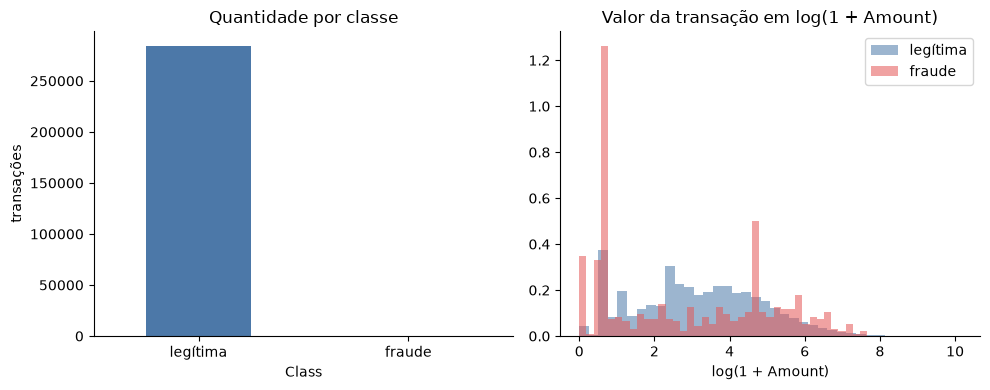

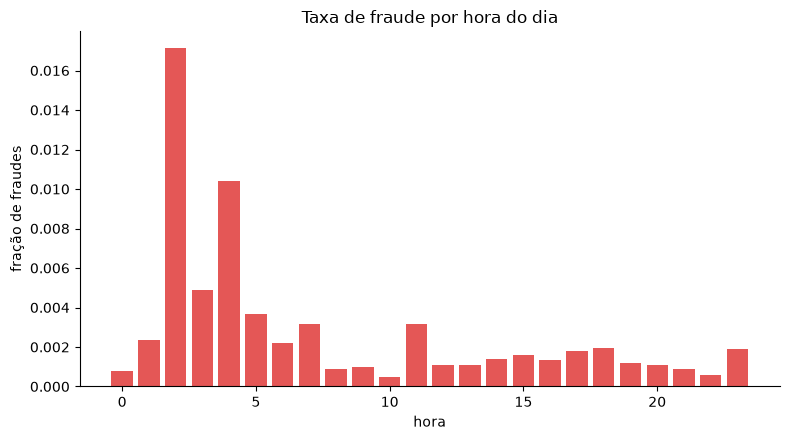

         mean  sum  count
hora                     
0.0   0.00078    6   7695
1.0   0.00237   10   4220
2.0   0.01713   57   3328
3.0   0.00487   17   3492
4.0   0.01041   23   2209
5.0   0.00368   11   2990
6.0   0.00219    9   4101
7.0   0.00318   23   7243
8.0   0.00088    9  10276
9.0   0.00101   16  15838
10.0  0.00048    8  16598
11.0  0.00314   53  16856
12.0  0.00110   17  15420
13.0  0.00111   17  15365
14.0  0.00139   23  16570
15.0  0.00158   26  16461
16.0  0.00134   22  16453
17.0  0.00179   29  16166
18.0  0.00194   33  17039
19.0  0.00121   19  15649
20.0  0.00107   18  16756
21.0  0.00090   16  17703
22.0  0.00058    9  15441
23.0  0.00192   21  10938


In [3]:
fig, eixos = plt.subplots(1, 2, figsize=(10, 4))

contagem.plot(kind="bar", ax=eixos[0], color=["#4C78A8", "#E45756"])
eixos[0].set_xticklabels(["legítima", "fraude"], rotation=0)
eixos[0].set_title("Quantidade por classe")
eixos[0].set_ylabel("transações")

for classe, cor, nome in [(0, "#4C78A8", "legítima"), (1, "#E45756", "fraude")]:
    valores = np.log1p(df.loc[df["Class"] == classe, "Amount"])
    eixos[1].hist(valores, bins=40, density=True, alpha=0.55, color=cor, label=nome)
eixos[1].set_title("Valor da transação em log(1 + Amount)")
eixos[1].set_xlabel("log(1 + Amount)")
eixos[1].legend()

fig.tight_layout()
plt.show()

hora_exploracao = (df["Time"] % (24 * 60 * 60)) // 3600
taxa_por_hora = df.assign(hora=hora_exploracao).groupby("hora")["Class"].agg(["mean", "sum", "count"])

fig, eixo = plt.subplots()
eixo.bar(taxa_por_hora.index, taxa_por_hora["mean"], color="#E45756")
eixo.set_title("Taxa de fraude por hora do dia")
eixo.set_xlabel("hora")
eixo.set_ylabel("fração de fraudes")
fig.tight_layout()
plt.show()

print(taxa_por_hora.round(5).to_string())


## 2. Preparar

Três decisões, nesta ordem:

1. **Variáveis novas, linha a linha.** `Amount_log` comprime valores muito altos. `hora` transforma `Time` (segundos desde a primeira transação) em hora do dia, porque a taxa de fraude não é plana ao longo das 24 horas. Não dá para criar "transações em sequência do mesmo cartão": a base não tem identificador de cliente.
2. **Separar treino, validação e teste com `stratify`.** A validação existe só para escolher o limiar. O teste fica guardado para a medida final. Sem `stratify`, um dos lados pode ficar quase sem fraude.
3. **Padronizar com `StandardScaler` ajustado só no treino.** `V1`–`V28` já são componentes de PCA; ainda assim o scaler entra em todas as colunas, como no roteiro, para `Time`, `Amount`, `Amount_log` e `hora` não dominarem a regressão logística por causa da escala. Ajustar o scaler na base inteira vazaria informação do teste.


In [4]:
dados = df.copy()
dados["Amount_log"] = np.log1p(dados["Amount"])
dados["hora"] = (dados["Time"] % (24 * 60 * 60)) / 3600

X = dados.drop(columns=["Class"])
y = dados["Class"].astype(int)

X_treino_val, X_teste, y_treino_val, y_teste = train_test_split(
    X, y, test_size=0.20, random_state=SEMENTE, stratify=y
)
X_treino, X_val, y_treino, y_val = train_test_split(
    X_treino_val, y_treino_val, test_size=0.20, random_state=SEMENTE, stratify=y_treino_val
)

scaler = StandardScaler()
colunas = X_treino.columns.tolist()
X_treino_s = pd.DataFrame(scaler.fit_transform(X_treino), columns=colunas, index=X_treino.index)
X_val_s = pd.DataFrame(scaler.transform(X_val), columns=colunas, index=X_val.index)
X_teste_s = pd.DataFrame(scaler.transform(X_teste), columns=colunas, index=X_teste.index)


def proporcao_fraude(serie):
    return float((serie == 1).mean())


print("Linhas — treino / validação / teste:", len(y_treino), len(y_val), len(y_teste))
print(
    "Fração de fraude — treino / validação / teste:",
    round(proporcao_fraude(y_treino), 5),
    round(proporcao_fraude(y_val), 5),
    round(proporcao_fraude(y_teste), 5),
)
print("Fraudes no teste:", int((y_teste == 1).sum()))


Linhas — treino / validação / teste: 182276 45569 56962
Fração de fraude — treino / validação / teste: 0.00173 0.00173 0.00172
Fraudes no teste: 98


## 3. Como o limiar é escolhido

Cada modelo devolve uma probabilidade de fraude. A classe prevista vira fraude quando essa probabilidade passa de um limiar.

Regra usada na **validação**, igual para todos os modelos:

- procurar limiares de 0,02 a 0,97;
- ficar só com os que alcançam **recall de fraude de pelo menos 0,80**;
- entre esses, escolher o de **maior F1**.

O piso de 0,80 coloca o recall na frente. O F1 impede o extremo inútil de alertar quase tudo. Se nenhum limiar chegar a 0,80, fica o maior F1 e isso é dito com clareza. O limiar escolhido na validação é aplicado **uma vez** no teste, sem novo ajuste.


In [5]:
def metricas_no_limiar(y_verdadeiro, probabilidade, limiar):
    previsto = (probabilidade >= limiar).astype(int)
    return {
        "limiar": float(limiar),
        "recall": recall_score(y_verdadeiro, previsto, pos_label=1, zero_division=0),
        "precisao": precision_score(y_verdadeiro, previsto, pos_label=1, zero_division=0),
        "f1": f1_score(y_verdadeiro, previsto, pos_label=1, zero_division=0),
        "acuracia": accuracy_score(y_verdadeiro, previsto),
    }


def escolher_limiar(y_verdadeiro, probabilidade, recall_minimo=RECALL_MINIMO):
    limiares = np.round(np.arange(0.02, 0.98, 0.01), 2)
    tabela = pd.DataFrame([
        metricas_no_limiar(y_verdadeiro, probabilidade, limiar) for limiar in limiares
    ])
    candidatos = tabela[tabela["recall"] >= recall_minimo]
    if candidatos.empty:
        escolha = tabela.loc[tabela["f1"].idxmax()]
        regra = (
            f"nenhum limiar atingiu recall {recall_minimo:.2f} na validação; "
            "usei o maior F1"
        )
    else:
        escolha = candidatos.loc[candidatos["f1"].idxmax()]
        regra = (
            f"maior F1 entre limiares com recall >= {recall_minimo:.2f} na validação"
        )
    return escolha, tabela, regra


def avaliar_modelo(nome, y_val_local, proba_val, y_teste_local, proba_teste):
    escolha, tabela_val, regra = escolher_limiar(y_val_local, proba_val)
    limiar = float(escolha["limiar"])
    no_teste = metricas_no_limiar(y_teste_local, proba_teste, limiar)
    no_padrao = metricas_no_limiar(y_teste_local, proba_teste, 0.5)
    return {
        "modelo": nome,
        "limiar": limiar,
        "regra": regra,
        "tabela_val": tabela_val,
        "recall_val": float(escolha["recall"]),
        "precisao_val": float(escolha["precisao"]),
        "f1_val": float(escolha["f1"]),
        "recall_teste": no_teste["recall"],
        "precisao_teste": no_teste["precisao"],
        "f1_teste": no_teste["f1"],
        "acuracia_teste": no_teste["acuracia"],
        "recall_teste_em_0.5": no_padrao["recall"],
        "precisao_teste_em_0.5": no_padrao["precisao"],
        "f1_teste_em_0.5": no_padrao["f1"],
    }


## 4. O baseline que não serve

Antes dos algoritmos, o classificador que sempre diz "legítima". A acurácia fica alta e o recall da fraude fica em zero. É o número contra o qual os outros modelos precisam se justificar.


In [6]:
proba_sempre_legitima = np.zeros(len(y_teste))
baseline = metricas_no_limiar(y_teste, proba_sempre_legitima, 0.5)
print(pd.Series(baseline, name="sempre_legitima").to_string())
print()
print("Acertos:", int((y_teste == 0).sum()), "de", len(y_teste))
print("Fraudes encontradas: 0")


limiar      0.50000
recall      0.00000
precisao    0.00000
f1          0.00000
acuracia    0.99828

Acertos: 56864 de 56962
Fraudes encontradas: 0


## 5. Treinar

Três modelos, todos no mesmo treino padronizado, com peso para a classe rara:

- **Regressão logística**, baseline linear. O `GridSearchCV` varia só `C` (força da regularização) e escolhe pelo F1 em validação cruzada estratificada. A busca fica pequena de propósito: o ganho de varrer dezenas de florestas não muda a pergunta deste projeto.
- **Random Forest**, com `class_weight="balanced"`.
- **XGBoost**, com `scale_pos_weight` igual ao número de legítimas dividido pelo número de fraudes no treino. É o peso da classe positiva dentro do XGBoost.

O peso muda o custo de errar uma fraude. Ele não reescreve o teste: validação e teste continuam com a proporção real.


In [7]:
busca = GridSearchCV(
    LogisticRegression(class_weight="balanced", max_iter=1000, solver="lbfgs"),
    param_grid={"C": [0.01, 0.1, 1.0, 10.0]},
    scoring="f1",
    cv=3,
    n_jobs=-1,
)
busca.fit(X_treino_s, y_treino)
log_reg = busca.best_estimator_

print("Melhor C:", busca.best_params_["C"])
print("F1 médio na validação cruzada:", round(busca.best_score_, 4))
print(
    pd.DataFrame(busca.cv_results_)[["param_C", "mean_test_score", "std_test_score"]]
    .sort_values("param_C")
    .to_string(index=False)
)


Melhor C: 0.01
F1 médio na validação cruzada: 0.1223
 param_C  mean_test_score  std_test_score
    0.01         0.122302        0.006331
    0.10         0.118529        0.006689
    1.00         0.117476        0.006841
   10.00         0.117200        0.006691


In [8]:
floresta = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=SEMENTE,
    n_jobs=-1,
)
floresta.fit(X_treino_s, y_treino)
print("Random Forest treinado.", floresta.n_estimators, "árvores, profundidade máxima", floresta.max_depth)


Random Forest treinado. 100 árvores, profundidade máxima 12


In [9]:
peso_positivo = float((y_treino == 0).sum() / (y_treino == 1).sum())
print("scale_pos_weight:", round(peso_positivo, 2))

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=peso_positivo,
    eval_metric="logloss",
    random_state=SEMENTE,
    n_jobs=-1,
    tree_method="hist",
)
xgb.fit(X_treino_s, y_treino)
print("XGBoost treinado.")


scale_pos_weight: 577.65


XGBoost treinado.


## 6. Avaliar

O relatório, a curva ROC e a curva de precisão-recall são lidos no **teste**, com o limiar congelado na validação. A ROC mostra a separação geral. Com fraude rara, a curva de precisão-recall é a mais honesta: ela não se deixa impressionar pela quantidade de legítimas.

A linha tracejada na curva de precisão-recall é a taxa de fraude no teste. Um modelo útil fica bem acima dela.


In [10]:
modelos = {
    "Regressão logística": log_reg,
    "Random Forest": floresta,
    "XGBoost": xgb,
}

avaliacoes = []
for nome, estimador in modelos.items():
    proba_val = estimador.predict_proba(X_val_s)[:, 1]
    proba_teste = estimador.predict_proba(X_teste_s)[:, 1]
    avaliacao = avaliar_modelo(nome, y_val, proba_val, y_teste, proba_teste)
    avaliacao["estimador"] = estimador
    avaliacao["proba_teste"] = proba_teste
    avaliacoes.append(avaliacao)
    print(nome)
    print(" ", avaliacao["regra"])
    print("  limiar escolhido:", avaliacao["limiar"])

comparacao = pd.DataFrame(avaliacoes)[[
    "modelo",
    "limiar",
    "recall_val",
    "f1_val",
    "recall_teste",
    "precisao_teste",
    "f1_teste",
    "acuracia_teste",
    "recall_teste_em_0.5",
    "f1_teste_em_0.5",
]].sort_values("f1_val", ascending=False)

modelo_escolhido = comparacao.iloc[0]["modelo"]
escolhido = next(item for item in avaliacoes if item["modelo"] == modelo_escolhido)

print()
print("Comparação (modelo escolhido pelo F1 na validação, métricas de teste na mesma linha):")
print(comparacao.round(4).to_string(index=False))
print()
print("Modelo escolhido:", modelo_escolhido, "| limiar:", escolhido["limiar"])


Regressão logística
  maior F1 entre limiares com recall >= 0.80 na validação
  limiar escolhido: 0.97


Random Forest
  maior F1 entre limiares com recall >= 0.80 na validação
  limiar escolhido: 0.31


XGBoost
  maior F1 entre limiares com recall >= 0.80 na validação
  limiar escolhido: 0.15

Comparação (modelo escolhido pelo F1 na validação, métricas de teste na mesma linha):
             modelo  limiar  recall_val  f1_val  recall_teste  precisao_teste  f1_teste  acuracia_teste  recall_teste_em_0.5  f1_teste_em_0.5
            XGBoost    0.15      0.8101  0.7619        0.8776          0.7227    0.7926          0.9992               0.8367           0.8283
      Random Forest    0.31      0.8101  0.7529        0.8776          0.6099    0.7197          0.9988               0.8469           0.8058
Regressão logística    0.97      0.8101  0.4830        0.8776          0.3755    0.5260          0.9973               0.9082           0.1148

Modelo escolhido: XGBoost | limiar: 0.15


Relatório no teste, limiar 0.15
              precision    recall  f1-score   support

    legítima     0.9998    0.9994    0.9996     56864
      fraude     0.7227    0.8776    0.7926        98

    accuracy                         0.9992     56962
   macro avg     0.8612    0.9385    0.8961     56962
weighted avg     0.9993    0.9992    0.9992     56962

Mesmo modelo no limiar padrão 0,5:
              precision    recall  f1-score   support

    legítima     0.9997    0.9997    0.9997     56864
      fraude     0.8200    0.8367    0.8283        98

    accuracy                         0.9994     56962
   macro avg     0.9099    0.9182    0.9140     56962
weighted avg     0.9994    0.9994    0.9994     56962

Matriz de confusão [linhas = real, colunas = previsto]
               prevista legítima  prevista fraude
real legítima              56831               33
real fraude                   12               86


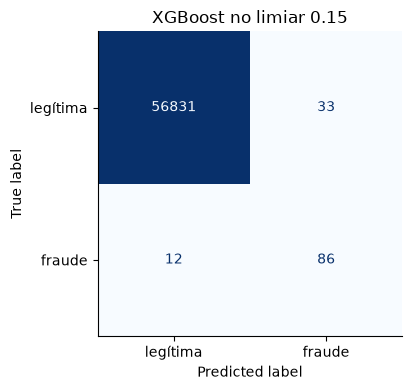

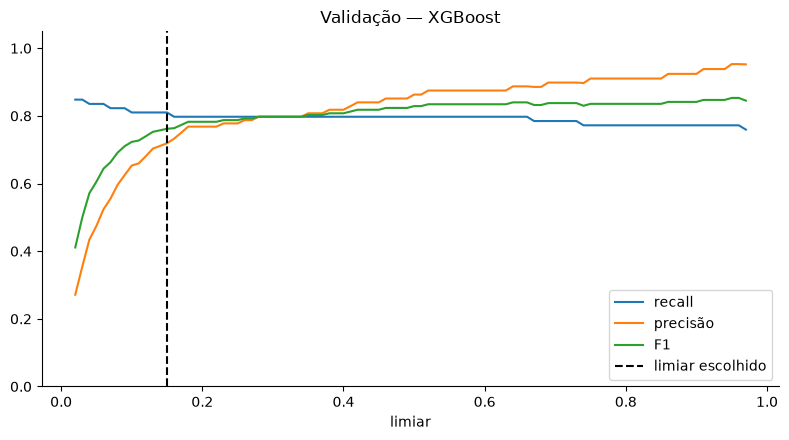

In [11]:
previsto = (escolhido["proba_teste"] >= escolhido["limiar"]).astype(int)
print("Relatório no teste, limiar", escolhido["limiar"])
print(classification_report(y_teste, previsto, target_names=["legítima", "fraude"], digits=4, zero_division=0))

print("Mesmo modelo no limiar padrão 0,5:")
previsto_padrao = (escolhido["proba_teste"] >= 0.5).astype(int)
print(classification_report(y_teste, previsto_padrao, target_names=["legítima", "fraude"], digits=4, zero_division=0))

matriz = confusion_matrix(y_teste, previsto)
print("Matriz de confusão [linhas = real, colunas = previsto]")
print(pd.DataFrame(matriz, index=["real legítima", "real fraude"], columns=["prevista legítima", "prevista fraude"]))

fig, eixo = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(matriz, display_labels=["legítima", "fraude"]).plot(ax=eixo, colorbar=False, cmap="Blues")
eixo.set_title(f"{modelo_escolhido} no limiar {escolhido['limiar']}")
fig.tight_layout()
plt.show()

tabela_val = escolhido["tabela_val"]
fig, eixo = plt.subplots()
eixo.plot(tabela_val["limiar"], tabela_val["recall"], label="recall")
eixo.plot(tabela_val["limiar"], tabela_val["precisao"], label="precisão")
eixo.plot(tabela_val["limiar"], tabela_val["f1"], label="F1")
eixo.axvline(escolhido["limiar"], color="black", linestyle="--", label="limiar escolhido")
eixo.set_title(f"Validação — {modelo_escolhido}")
eixo.set_xlabel("limiar")
eixo.set_ylim(0, 1.05)
eixo.legend()
fig.tight_layout()
plt.show()


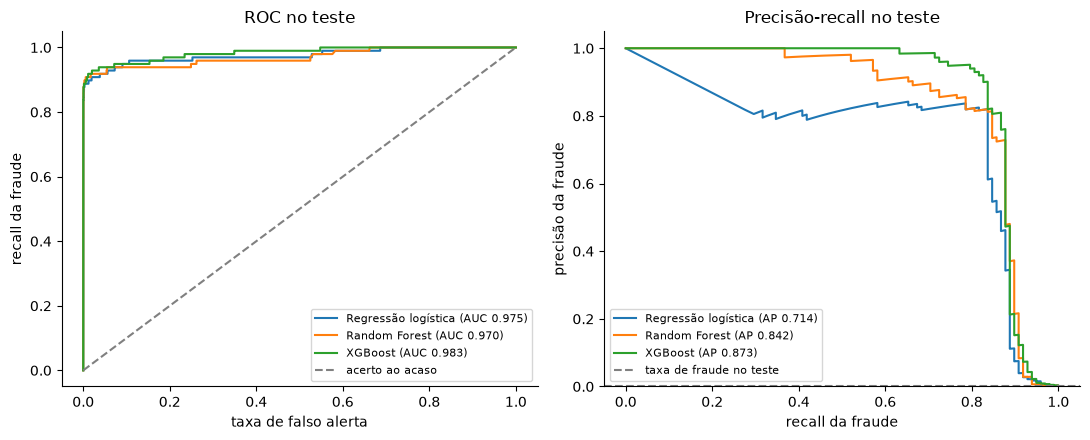

In [12]:
prevalencia_teste = float(y_teste.mean())

fig, eixos = plt.subplots(1, 2, figsize=(11, 4.5))
for item in avaliacoes:
    fpr, tpr, _ = roc_curve(y_teste, item["proba_teste"])
    auc = roc_auc_score(y_teste, item["proba_teste"])
    eixos[0].plot(fpr, tpr, label=f"{item['modelo']} (AUC {auc:.3f})")

    precisao, recall, _ = precision_recall_curve(y_teste, item["proba_teste"])
    ap = average_precision_score(y_teste, item["proba_teste"])
    eixos[1].plot(recall, precisao, label=f"{item['modelo']} (AP {ap:.3f})")

eixos[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="acerto ao acaso")
eixos[0].set_title("ROC no teste")
eixos[0].set_xlabel("taxa de falso alerta")
eixos[0].set_ylabel("recall da fraude")
eixos[0].legend(fontsize=8)

eixos[1].axhline(prevalencia_teste, linestyle="--", color="gray", label="taxa de fraude no teste")
eixos[1].set_title("Precisão-recall no teste")
eixos[1].set_xlabel("recall da fraude")
eixos[1].set_ylabel("precisão da fraude")
eixos[1].set_ylim(0, 1.05)
eixos[1].legend(fontsize=8)

fig.tight_layout()
plt.show()


## 7. Undersampling e oversampling

A regra prática é testar, não escolher no escuro. Os dois métodos entram **só na regressão logística** e **só no treino**:

- undersampling sorteia legítimas até empatar com o número de fraudes;
- oversampling repete fraudes até empatar com o número de legítimas.

Validação e teste permanecem na proporção real. O peso de classe sai desses dois ajustes, porque a amostra de treino já foi equilibrada. A comparação inclui também a logística sem peso nenhum, para ver o que acontece quando o desbalanceamento é ignorado.

O limiar de cada variante segue a mesma regra da validação.


In [13]:
def reamostrar(X_base, y_base, metodo, gerador):
    y_array = y_base.to_numpy()
    idx_fraude = np.flatnonzero(y_array == 1)
    idx_legitima = np.flatnonzero(y_array == 0)
    if metodo == "under":
        escolhidas = gerador.choice(idx_legitima, size=idx_fraude.size, replace=False)
        indices = np.concatenate([idx_fraude, escolhidas])
    elif metodo == "over":
        extras = gerador.choice(idx_fraude, size=idx_legitima.size - idx_fraude.size, replace=True)
        indices = np.concatenate([idx_legitima, idx_fraude, extras])
    else:
        raise ValueError(metodo)
    gerador.shuffle(indices)
    return X_base.iloc[indices], y_base.iloc[indices]


def treinar_logistica(X_base, y_base):
    modelo = LogisticRegression(max_iter=1000, solver="lbfgs")
    modelo.fit(X_base, y_base)
    return modelo


gerador = np.random.default_rng(SEMENTE)
variantes = {
    "sem tratamento": (X_treino_s, y_treino, treinar_logistica(X_treino_s, y_treino)),
}

for metodo in ("under", "over"):
    X_eq, y_eq = reamostrar(X_treino_s, y_treino, metodo, gerador)
    variantes[metodo] = (X_eq, y_eq, treinar_logistica(X_eq, y_eq))
    print(metodo, "— linhas de treino:", len(y_eq), "| fraudes:", int((y_eq == 1).sum()))

# A logística com peso já foi treinada na busca de C. Entra na mesma tabela.
variantes["class_weight"] = (X_treino_s, y_treino, log_reg)

linhas_balanceamento = []
for nome, (_, _, estimador) in variantes.items():
    medida = avaliar_modelo(
        nome,
        y_val,
        estimador.predict_proba(X_val_s)[:, 1],
        y_teste,
        estimador.predict_proba(X_teste_s)[:, 1],
    )
    linhas_balanceamento.append(medida)

tabela_balanceamento = pd.DataFrame(linhas_balanceamento)[[
    "modelo", "limiar", "recall_teste", "precisao_teste", "f1_teste", "acuracia_teste"
]].sort_values("recall_teste", ascending=False)

print()
print("Regressão logística no teste, limiar escolhido na validação:")
print(tabela_balanceamento.round(4).to_string(index=False))


under — linhas de treino: 630 | fraudes: 315


over — linhas de treino: 363922 | fraudes: 181961



Regressão logística no teste, limiar escolhido na validação:
        modelo  limiar  recall_teste  precisao_teste  f1_teste  acuracia_teste
         under    0.97        0.8776          0.2216    0.3539          0.9945
          over    0.97        0.8776          0.3373    0.4873          0.9968
  class_weight    0.97        0.8776          0.3755    0.5260          0.9973
sem tratamento    0.03        0.8265          0.5827    0.6835          0.9987


## 8. Explicar a decisão

Duas leituras, do geral para o caso:

1. **Importância global** do modelo escolhido: quanto cada variável entra nas divisões (árvore) ou no coeficiente (logística). Importância de árvore diz o quanto a variável foi usada, não se ela empurra a transação para fraude ou para legítima.
2. **SHAP**, no mesmo modelo, numa amostra do teste. O valor SHAP é a contribuição daquela variável para a probabilidade prevista naquela linha. Positivo empurra para fraude; negativo empurra para legítima.

`V1`–`V28` não têm nome de negócio. Dá para dizer *quais* componentes pesaram, e não *qual dado cadastral* isso era. Essa é uma limitação da base, não do gráfico.


V14           0.3939
V4            0.1074
V8            0.0390
V12           0.0358
V20           0.0328
V17           0.0312
Amount_log    0.0304
Amount        0.0291
V10           0.0284
V13           0.0244
V3            0.0236
V11           0.0212
V19           0.0189
V7            0.0176
V26           0.0170


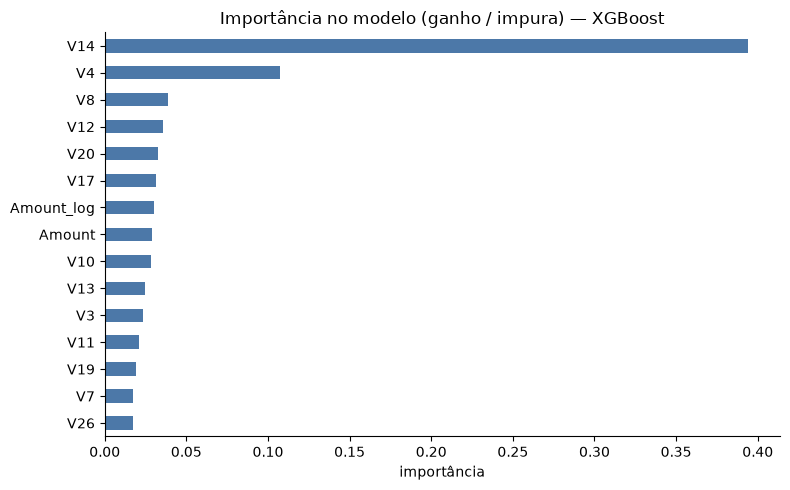

In [14]:
estimador = escolhido["estimador"]
nomes = X_teste_s.columns

if hasattr(estimador, "feature_importances_"):
    importancia = pd.Series(estimador.feature_importances_, index=nomes)
    titulo_imp = "Importância no modelo (ganho / impura)"
else:
    importancia = pd.Series(np.abs(estimador.coef_[0]), index=nomes)
    titulo_imp = "Módulo do coeficiente na regressão logística"

top_imp = importancia.sort_values(ascending=False).head(15)
print(top_imp.round(4).to_string())

fig, eixo = plt.subplots(figsize=(8, 5))
top_imp.sort_values().plot(kind="barh", ax=eixo, color="#4C78A8")
eixo.set_title(titulo_imp + f" — {modelo_escolhido}")
eixo.set_xlabel("importância")
fig.tight_layout()
plt.show()


Média do |SHAP| na amostra do teste — XGBoost
V14     2.0561
V4      1.8465
V12     0.9856
V10     0.7530
V8      0.7502
V3      0.5840
V11     0.5436
V1      0.4748
V26     0.4187
V16     0.4022
hora    0.3677
V17     0.3558


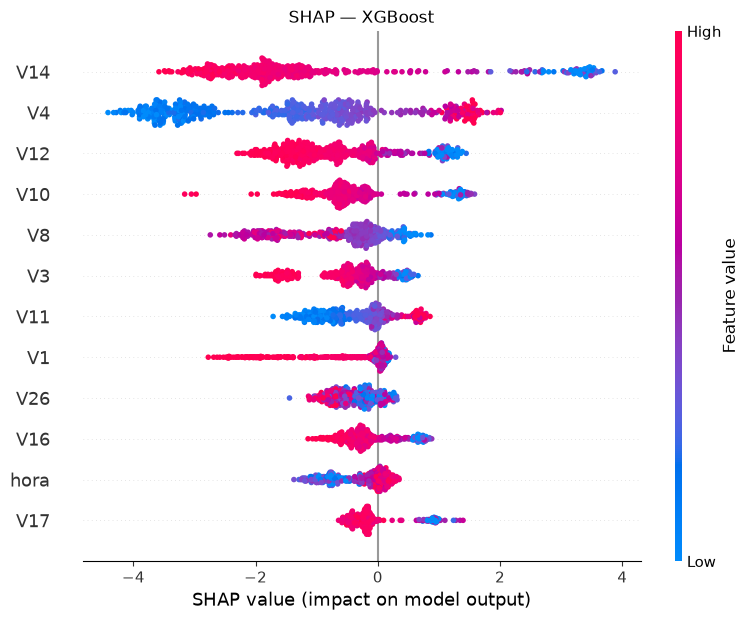

In [15]:
gerador_shap = np.random.default_rng(SEMENTE)
idx_fraude = y_teste[y_teste == 1].index.to_numpy()
idx_legitima = y_teste[y_teste == 0].index.to_numpy()
amostra_idx = np.concatenate([
    gerador_shap.choice(idx_fraude, size=min(80, idx_fraude.size), replace=False),
    gerador_shap.choice(idx_legitima, size=400, replace=False),
])
X_amostra = X_teste_s.loc[amostra_idx]


def extrair_shap(valores):
    if isinstance(valores, list):
        return np.asarray(valores[1])
    valores = np.asarray(valores)
    if valores.ndim == 3:
        return valores[:, :, 1]
    return valores


def criar_explicador(estimador_alvo):
    if isinstance(estimador_alvo, LogisticRegression):
        fundo = X_treino_s.sample(300, random_state=SEMENTE)
        return shap.LinearExplainer(estimador_alvo, fundo)
    return shap.TreeExplainer(estimador_alvo)


modelo_shap = modelo_escolhido
estimador_shap = estimador
try:
    explicador = criar_explicador(estimador_shap)
    shap_amostra = extrair_shap(explicador.shap_values(X_amostra))
except Exception as erro:
    print("SHAP no modelo escolhido não rodou:", type(erro).__name__, erro)
    print("A explicação segue com o Random Forest, também treinado nesta comparação.")
    modelo_shap = "Random Forest"
    estimador_shap = floresta
    explicador = shap.TreeExplainer(estimador_shap)
    shap_amostra = extrair_shap(explicador.shap_values(X_amostra))

media_abs = pd.Series(np.abs(shap_amostra).mean(axis=0), index=X_amostra.columns).sort_values(ascending=False)
print("Média do |SHAP| na amostra do teste —", modelo_shap)
print(media_abs.head(12).round(4).to_string())

shap.summary_plot(shap_amostra, X_amostra, show=False, max_display=12)
plt.title(f"SHAP — {modelo_shap}")
plt.tight_layout()
plt.show()


Caso de fraude com maior probabilidade no teste
classe real: 1 | probabilidade de fraude: 1.0
limiar do modelo: 0.15
     valor_padronizado    shap
V14           -14.3072  3.5082
V10           -11.7498  1.3855
V12           -13.0837  1.3031
V4              6.3010  1.2504
V17           -24.2991  0.9671
V11             6.6566  0.7870
V16           -12.5202  0.7582
V8              5.6059 -0.5340

Caso legítimo cuja probabilidade ficou mais perto do limiar
classe real: 0 | probabilidade de fraude: 0.1496
limiar do modelo: 0.15
     valor_padronizado    shap
V8              0.8231 -1.7234
V4              2.5278  1.4056
V11            -0.1822 -1.2965
V14            -2.1970  0.9031
V22            -1.8541 -0.8884
V17            -4.1805  0.8243
V16            -3.0027  0.6397
V28             1.3422 -0.5960



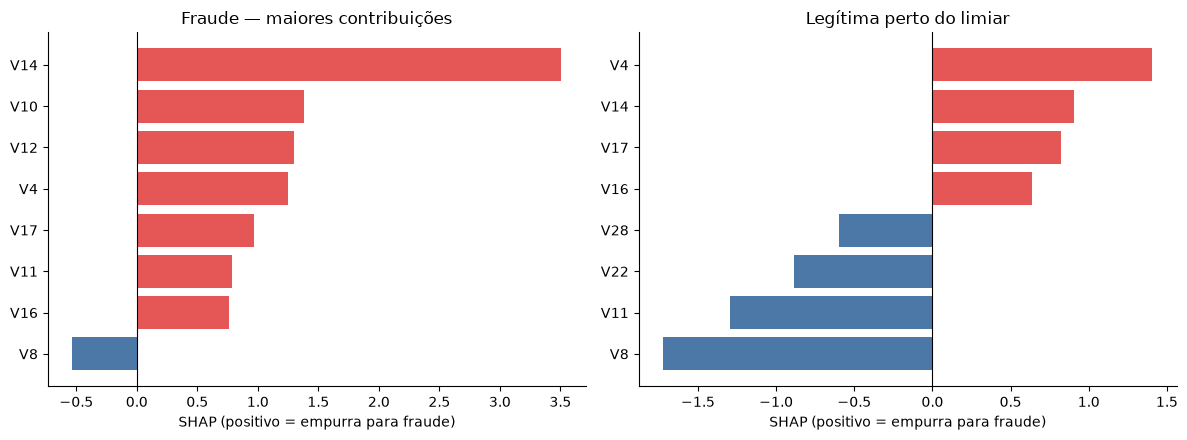

In [16]:
def explicar_transacao(indice, titulo):
    linha = X_teste_s.loc[[indice]]
    valores = np.asarray(extrair_shap(explicador.shap_values(linha)))
    if valores.ndim == 2:
        valores = valores[0]
    contribuicao = pd.Series(valores, index=linha.columns)
    ordem = contribuicao.abs().sort_values(ascending=False).head(8).index
    tabela = pd.DataFrame({
        "valor_padronizado": linha.iloc[0][ordem].to_numpy(),
        "shap": contribuicao[ordem].to_numpy(),
    }, index=ordem)
    probabilidade = float(estimador_shap.predict_proba(linha)[0, 1])
    classe_real = int(y_teste.loc[indice])
    print(titulo)
    print("classe real:", classe_real, "| probabilidade de fraude:", round(probabilidade, 4))
    print("limiar do modelo:", escolhido["limiar"] if modelo_shap == modelo_escolhido else "(explicação no Random Forest)")
    print(tabela.round(4).to_string())
    print()
    return contribuicao


fraudes_teste = y_teste[y_teste == 1]
prob_fraudes = pd.Series(escolhido["proba_teste"], index=y_teste.index).loc[fraudes_teste.index]
indice_fraude = prob_fraudes.idxmax()

legitimas_teste = y_teste[y_teste == 0]
prob_legitimas = pd.Series(escolhido["proba_teste"], index=y_teste.index).loc[legitimas_teste.index]
indice_legitima = (prob_legitimas - escolhido["limiar"]).abs().idxmin()

contribuicao_fraude = explicar_transacao(indice_fraude, "Caso de fraude com maior probabilidade no teste")
contribuicao_legitima = explicar_transacao(
    indice_legitima,
    "Caso legítimo cuja probabilidade ficou mais perto do limiar",
)

fig, eixos = plt.subplots(1, 2, figsize=(12, 4.5))
for eixo, contrib, titulo in [
    (eixos[0], contribuicao_fraude, "Fraude — maiores contribuições"),
    (eixos[1], contribuicao_legitima, "Legítima perto do limiar"),
]:
    top = contrib.reindex(contrib.abs().sort_values(ascending=False).head(8).index).sort_values()
    cores = ["#E45756" if valor > 0 else "#4C78A8" for valor in top]
    eixo.barh(top.index, top.values, color=cores)
    eixo.axvline(0, color="black", linewidth=0.8)
    eixo.set_title(titulo)
    eixo.set_xlabel("SHAP (positivo = empurra para fraude)")
fig.tight_layout()
plt.show()


## 9. O que este notebook decide

- A métrica que manda é o **recall da fraude**, com um piso de 0,80 na validação. Precisão e F1 entram para o limiar não virar "alertar tudo".
- O modelo da entrega é o de **maior F1 na validação** entre logística, Random Forest e XGBoost, no limiar dessa regra. Os números de teste dos três ficam na tabela para comparação, mas a escolha não foi feita olhando o teste.
- Undersampling e oversampling foram testados na logística. O que ganha em recall nessa tabela é um resultado medido, não uma preferência antecipada.
- O SHAP mostra o peso de cada variável numa transação. Como `V1`–`V28` são anônimos, a explicação chega até o componente, não até o campo original do cliente.

Em relação ao roteiro da Expert, quatro coisas foram feitas de outro jeito: a validação foi separada do teste para o limiar não ser ajustado na prova final; undersampling e oversampling foram medidos lado a lado contra o peso de classe; `hora` foi criada a partir de `Time`, sem inventar sequência de cartão; o `GridSearchCV` ficou restrito ao `C` da regressão logística. Esse F1 da validação cruzada usa o limiar 0,5. Com peso de classe, 0,5 gera alerta demais, então o F1 da busca fica baixo e não é a métrica final do modelo.


In [17]:
print("RESUMO")
print("modelo:", modelo_escolhido)
print("limiar:", escolhido["limiar"])
print("regra:", escolhido["regra"])
print(
    "teste — recall / precisão / F1 / acurácia:",
    round(escolhido["recall_teste"], 4),
    round(escolhido["precisao_teste"], 4),
    round(escolhido["f1_teste"], 4),
    round(escolhido["acuracia_teste"], 4),
)
print("variáveis com maior |SHAP| médio:", list(media_abs.head(5).index))
melhor_f1_log = tabela_balanceamento.sort_values("f1_teste", ascending=False).iloc[0]
print(
    "Na logística, maior F1 no teste:",
    melhor_f1_log["modelo"],
    "| F1",
    round(melhor_f1_log["f1_teste"], 4),
    "| recall",
    round(melhor_f1_log["recall_teste"], 4),
)
print("Recall máximo nessa tabela:", round(tabela_balanceamento["recall_teste"].max(), 4))


RESUMO
modelo: XGBoost
limiar: 0.15
regra: maior F1 entre limiares com recall >= 0.80 na validação
teste — recall / precisão / F1 / acurácia: 0.8776 0.7227 0.7926 0.9992
variáveis com maior |SHAP| médio: ['V14', 'V4', 'V12', 'V10', 'V8']
Na logística, maior F1 no teste: sem tratamento | F1 0.6835 | recall 0.8265
Recall máximo nessa tabela: 0.8776
